In [27]:
# Modelos de regresión tradicionales
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Función para entrenar y evaluar modelos clásicos
def entrenar_evaluar_regresor(model_class, X_train, X_test, y_train, y_test, **kwargs):
    """
    Entrena y evalúa un modelo de regresión clásico.
    Args:
        model_class: clase del modelo (ej. LinearRegression)
        X_train, X_test, y_train, y_test: datos
        kwargs: hiperparámetros
    Returns:
        modelo entrenado, predicciones
    """
    model = model_class(**kwargs)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred

# Función para ejecutar experimentos con modelos clásicos
def ejecutar_experimentos_regresores(X_train, X_test, y_train, y_test, modelos_param_grid):
    resultados = []
    modelos = []
    for i, (model_class, params) in enumerate(modelos_param_grid):
        print(f"\nEntrenando modelo clásico {i+1}: {model_class.__name__} con params: {params}")
        model, y_pred = entrenar_evaluar_regresor(model_class, X_train, X_test, y_train, y_test, **params)
        metrics, residuals = calcular_metricas(y_test, y_pred)
        resultados.append({'model_class': model_class.__name__, 'params': params, 'metrics': metrics, 'residuals': residuals, 'y_pred': y_pred})
        modelos.append(model)
    return resultados, modelos

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Función para graficar la curva ROC de un modelo

def plot_roc_curve(model, X_test, y_test, model_name=None):
    """
    Grafica la curva ROC para un modelo dado.
    Args:
        model: modelo entrenado (debe tener predict_proba o decision_function)
        X_test: datos de prueba
        y_test: etiquetas verdaderas
        model_name: nombre del modelo (opcional)
    """
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        raise ValueError("El modelo debe tener predict_proba o decision_function")
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    title = f'ROC Curve - {model_name}' if model_name else 'ROC Curve'
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()


# Entrenamiento, comparación y análisis visual de modelos MLPRegressor

Este notebook permite entrenar, comparar y analizar modelos de regresión tipo MLP utilizando funciones reutilizables para entrenamiento, visualización y evaluación. Al final, se incluye un reporte en LaTeX con interpretación y ejemplos numéricos.

In [29]:
! pip install pandas scikit-learn seaborn matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


In [30]:
import sys
sys.path.append('../../')

In [31]:
# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score, max_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

In [32]:
# 2. Definir función para crear y entrenar modelos

def entrenar_evaluar_mlp(X_train, X_test, y_train, y_test, 
                        hidden_layer_sizes=(16,), activation='relu', solver='adam',
                        learning_rate='adaptive', learning_rate_init=0.001, max_iter=1000, 
                        random_state=42, validation_fraction=0.1, n_iter_no_change=20, verbose=False):
    """
    Entrena y evalúa un MLPRegressor con los hiperparámetros dados.
    Devuelve el modelo entrenado, predicciones y métricas.
    """
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        learning_rate=learning_rate,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=random_state,
        validation_fraction=validation_fraction,
        n_iter_no_change=n_iter_no_change,
        verbose=verbose
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, y_pred

In [33]:
# 3. Definir funciones para visualizaciones

def plot_histograma_residuos(residuals):
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=50, color='skyblue', edgecolor='black')
    plt.title('Histograma de errores residuales')
    plt.xlabel('Error (valor real - predicción)')
    plt.ylabel('Frecuencia')
    plt.show()

def plot_dispersion_residuos(y_pred, residuals):
    plt.figure(figsize=(8, 4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicción (y_pred)')
    plt.ylabel('Error residual (real - predicción)')
    plt.title('Dispersión de residuos vs. predicción')
    plt.show()

def plot_boxplot_errores_abs(residuals):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=np.abs(residuals))
    plt.title('Boxplot de errores absolutos')
    plt.xlabel('Error absoluto |real - predicción|')
    plt.show()

In [34]:
# 4. Definir función para calcular métricas de evaluación

def calcular_metricas(y_true, y_pred):
    residuals = y_true - y_pred
    metrics = {
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'medae': np.median(np.abs(residuals)),
        'evs': explained_variance_score(y_true, y_pred),
        'max_error': max_error(y_true, y_pred),
        'mape': mean_absolute_percentage_error(y_true, y_pred),
        'pearson': pearsonr(y_true, y_pred)[0]
    }
    return metrics, residuals

In [35]:
# 5. Definir función para ejecutar experimentos con diferentes hiperparámetros y guardar modelos

def ejecutar_experimentos(X_train, X_test, y_train, y_test, param_grid):
    resultados = []
    modelos = []
    for i, params in enumerate(param_grid):
        print(f"\nEntrenando modelo {i+1} con params: {params}")
        model, y_pred = entrenar_evaluar_mlp(
            X_train, X_test, y_train, y_test,
            hidden_layer_sizes=params.get('hidden_layer_sizes', (16,)),
            activation=params.get('activation', 'relu'),
            solver=params.get('solver', 'adam'),
            learning_rate=params.get('learning_rate', 'adaptive'),
            learning_rate_init=params.get('learning_rate_init', 0.001),
            max_iter=params.get('max_iter', 1000),
            random_state=params.get('random_state', 42),
            validation_fraction=params.get('validation_fraction', 0.1),
            n_iter_no_change=params.get('n_iter_no_change', 20),
            verbose=False
        )
        metrics, residuals = calcular_metricas(y_test, y_pred)
        resultados.append({'params': params, 'metrics': metrics, 'residuals': residuals, 'y_pred': y_pred})
        modelos.append(model)
    return resultados, modelos

In [36]:
# 7. Generar visualizaciones y métricas para cada modelo

def analizar_resultados(resultados, y_test):
    for i, res in enumerate(resultados):
        print(f"\nModelo {i+1} - Hiperparámetros: {res['params']}")
        print("Métricas:")
        for k, v in res['metrics'].items():
            print(f"  {k}: {v:.4f}")
        plot_histograma_residuos(res['residuals'])
        plot_dispersion_residuos(res['y_pred'], res['residuals'])
        plot_boxplot_errores_abs(res['residuals'])



In [37]:
# 8. Comparar modelos y mostrar resultados en tabla

def tabla_comparacion(resultados):
    filas = []
    for i, res in enumerate(resultados):
        fila = {'Modelo': i+1}
        fila.update(res['params'])
        fila.update(res['metrics'])
        filas.append(fila)
    df_resultados = pd.DataFrame(filas)
    display(df_resultados.sort_values('r2', ascending=False))


# Experimentacion y evaluacion de modelos

In [38]:
# 1. Importar librerías
from app.database import get_db
from app.services import resultado
from sklearn.impute import SimpleImputer

In [39]:
# 2. Obtener datos de la base de datos
db = next(get_db())
resultados = resultado.get_resultados(db)
df = pd.DataFrame(resultados)

In [40]:
# Analisis exploratorio
print("Primeras filas del dataset:")
df.head()

print("\nInformación del dataset:")
df.info()

print ("\nEstadísticas descriptivas:")
df.describe()


Primeras filas del dataset:

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   resultado_Color_Aparente          14210 non-null  object
 1   diagnostico_Color_Aparente        14210 non-null  object
 2   resultado_Turbiedad               14968 non-null  object
 3   diagnostico_Turbiedad             14968 non-null  object
 4   resultado_Ph                      15289 non-null  object
 5   diagnostico_Ph                    15289 non-null  object
 6   resultado_Cloro_Residual_Libre    9019 non-null   object
 7   diagnostico_Cloro_Residual_Libre  9019 non-null   object
 8   resultado_Alcalinidad_Total       4238 non-null   object
 9   diagnostico_Alcalinidad_Total     4238 non-null   object
 10  resultado_Aluminio                1199 non-null   object
 11  diagnostico_Aluminio      

,resultado_Color_Aparente,diagnostico_Color_Aparente,resultado_Turbiedad,diagnostico_Turbiedad,resultado_Ph,diagnostico_Ph,resultado_Cloro_Residual_Libre,diagnostico_Cloro_Residual_Libre,resultado_Alcalinidad_Total,diagnostico_Alcalinidad_Total,...,resultado_Coliformes_Totales,diagnostico_Coliformes_Totales,resultado_E_Coli,diagnostico_E_Coli,resultado_Floruros,diagnostico_Floruros,resultado_Hierro_Total,diagnostico_Hierro_Total,IRCA,nivel_Riesgo
count,14210,14210,14968,14968,15289,15289,9019,9019,4238,4238,...,15343,15343,15300,15300,1230,1230,3830,3830,15376,15376
unique,24,2,137,2,136,2,230,2,177,2,...,590,2,667,2,7,2,105,2,531,5
top,5.00,Aceptable,0.50,Aceptable,7.00,Aceptable,0.00,Aceptable,20.00,Aceptable,...,0E-10,No aceptable,0E-10,No aceptable,0.50,Aceptable,0.06,Aceptable,0.00,ALTO
freq,8221,11607,3883,11146,3758,14784,1994,5952,1006,4222,...,5333,10010,7450,7850,1223,1226,683,3025,3878,6344


In [41]:
# 3. Análisis de nulos y limpieza de columnas
porcentajes_nulos = df.isnull().mean() * 100
umbral_eliminar = 70  # eliminar columnas con >70% de nulos
columnas_eliminar = porcentajes_nulos[porcentajes_nulos > umbral_eliminar].index.tolist()
df = df.drop(columns=columnas_eliminar)

In [42]:
# info después de eliminar columnas
print("\nInformación del dataset después de eliminar columnas con muchos nulos:")
df.info()


Información del dataset después de eliminar columnas con muchos nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15376 entries, 0 to 15375
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   resultado_Color_Aparente          14210 non-null  object
 1   diagnostico_Color_Aparente        14210 non-null  object
 2   resultado_Turbiedad               14968 non-null  object
 3   diagnostico_Turbiedad             14968 non-null  object
 4   resultado_Ph                      15289 non-null  object
 5   diagnostico_Ph                    15289 non-null  object
 6   resultado_Cloro_Residual_Libre    9019 non-null   object
 7   diagnostico_Cloro_Residual_Libre  9019 non-null   object
 8   resultado_Cloruros                5454 non-null   object
 9   diagnostico_Cloruros              5454 non-null   object
 10  resultado_Nitritos                6327 non-null   object
 11  diagnost

In [43]:
# 4. Selección y limpieza de columnas numéricas y categóricas
numerical_columns = [col for col in df.columns if 'resultado' in col.lower()]
categorical_columns = [col for col in df.columns if 'diagnostico' in col.lower()]
df.drop(columns=categorical_columns, inplace=True)
df.drop(columns=['nivel_Riesgo'], inplace=True)
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['IRCA'] = pd.to_numeric(df['IRCA'], errors='coerce')

In [44]:
# 5. Imputación de valores nulos en columnas numéricas
imputer_num = SimpleImputer(strategy="mean")
df[numerical_columns] = imputer_num.fit_transform(df[numerical_columns])

In [45]:
df

,resultado_Color_Aparente,resultado_Turbiedad,resultado_Ph,resultado_Cloro_Residual_Libre,resultado_Cloruros,resultado_Nitritos,resultado_Coliformes_Totales,resultado_E_Coli,IRCA
0,5.0,2.137046,7.0,0.661431,7.500000,0.01,2419.600000,105.0,73.39
1,5.0,0.500000,7.0,0.661431,7.500000,0.01,1553.100000,117.8,57.55
2,5.0,0.600000,7.0,0.500000,7.500000,0.01,2419.600000,105.0,57.55
3,5.0,0.500000,7.0,0.500000,7.500000,0.01,765.679398,0.0,100.00
4,5.0,0.500000,7.0,0.500000,7.500000,0.01,0.000000,0.0,0.00
...,...,...,...,...,...,...,...,...,...
15371,5.0,0.500000,7.0,0.000000,9.323559,0.01,25.900000,0.0,37.27
15372,5.0,0.500000,7.1,0.661431,9.323559,0.01,32.700000,0.0,22.90
15373,40.0,7.400000,6.9,0.661431,9.323559,0.01,2419.600000,172.3,93.13
15374,30.0,3.100000,6.8,0.661431,9.323559,0.01,69.700000,8.6,93.13


In [46]:
# 6. División de datos en características y objetivo
X = df.drop(columns=['IRCA'], axis=1)
y = df['IRCA']

In [47]:
# 7. Normalización de datos
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

In [48]:
# 8. División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Entrenando modelo 1 con params: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 2 con params: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 2 con params: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 3 con params: {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 3 con params: {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}

Entrenando modelo 4 con params: {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001}

Entrenando modelo 4 con params: {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001}

Entrenando modelo 5 con params: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01}

Entrenando modelo 5 con params: {'hidden_layer_sizes': (16,), 'activation': 'relu', 

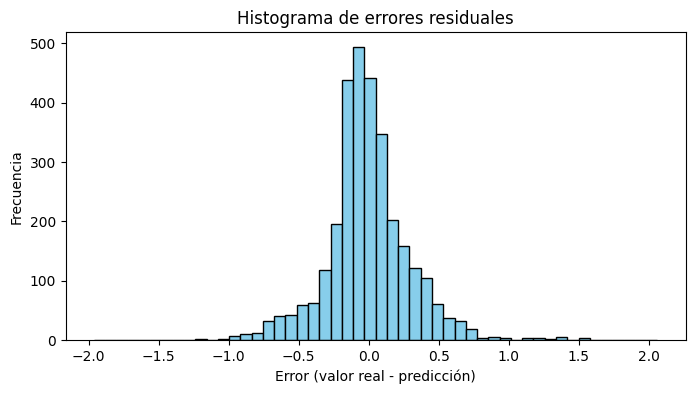

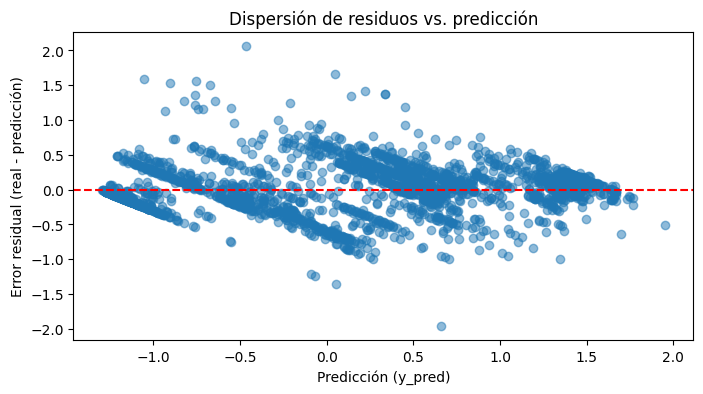

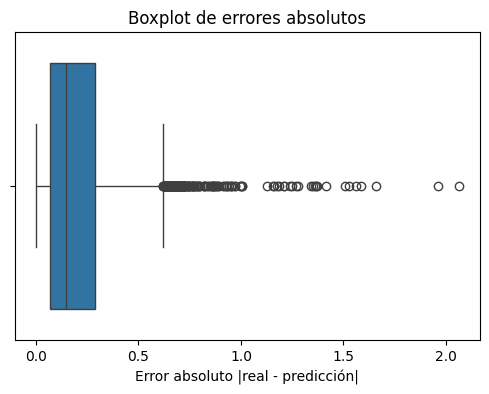


Modelo 2 - Hiperparámetros: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.0765
  rmse: 0.2766
  r2: 0.9245
  mae: 0.1808
  medae: 0.0985
  evs: 0.9245
  max_error: 2.2097
  mape: 0.4010
  pearson: 0.9616


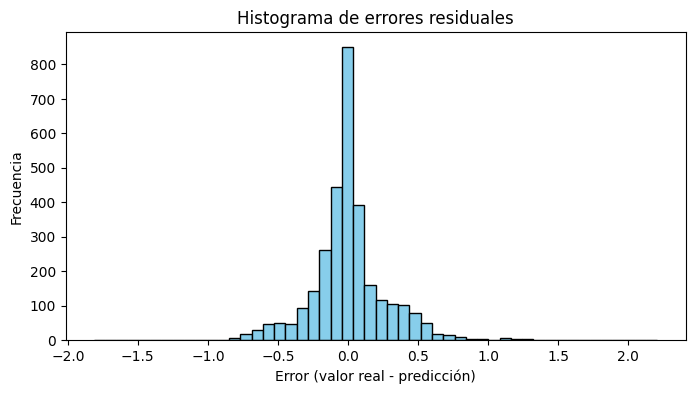

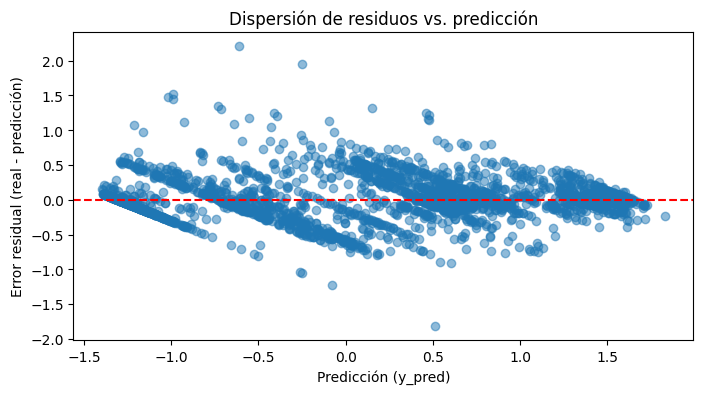

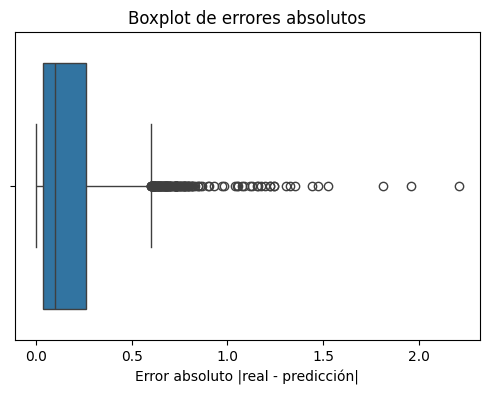


Modelo 3 - Hiperparámetros: {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.0432
  rmse: 0.2078
  r2: 0.9574
  mae: 0.1318
  medae: 0.0773
  evs: 0.9577
  max_error: 2.3279
  mape: 0.2820
  pearson: 0.9786


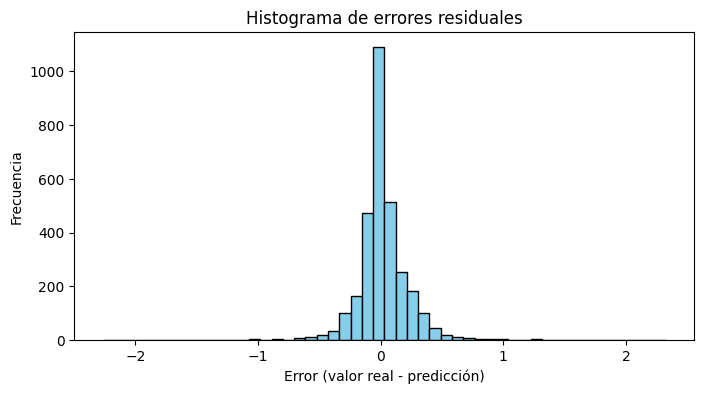

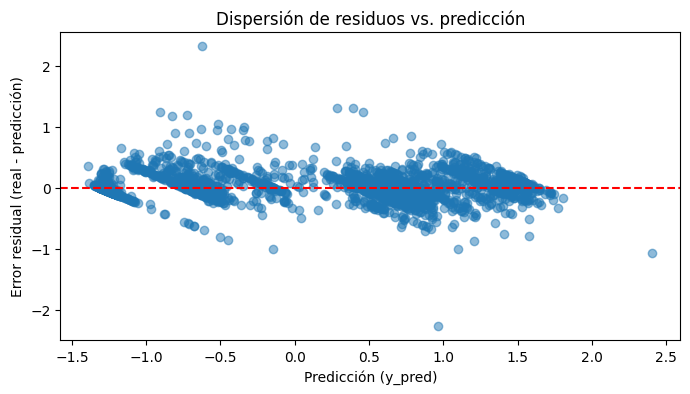

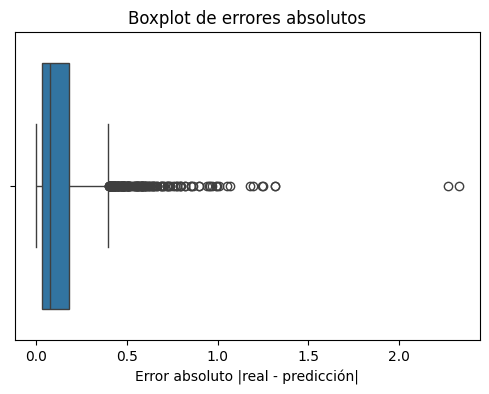


Modelo 4 - Hiperparámetros: {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001}
Métricas:
  mse: 0.1159
  rmse: 0.3405
  r2: 0.8856
  mae: 0.2271
  medae: 0.1449
  evs: 0.8856
  max_error: 2.4465
  mape: 0.4781
  pearson: 0.9412


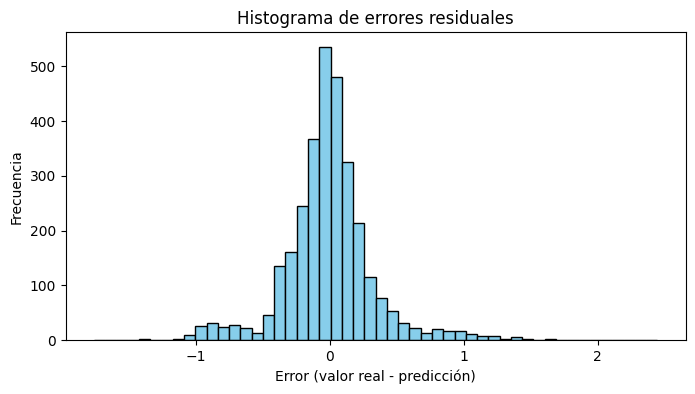

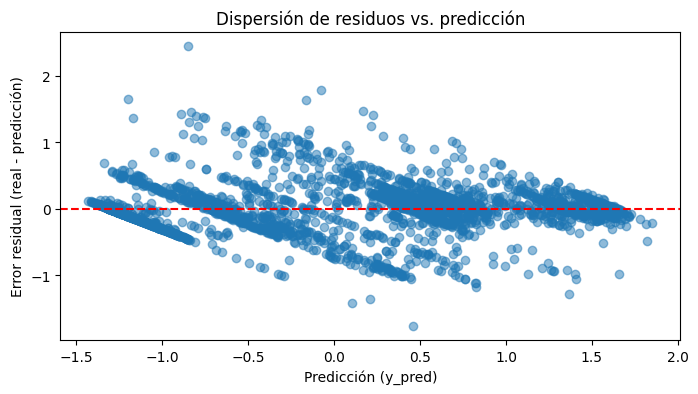

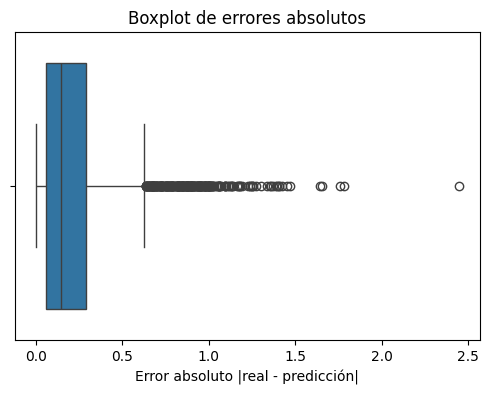


Modelo 5 - Hiperparámetros: {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01}
Métricas:
  mse: 0.0600
  rmse: 0.2450
  r2: 0.9408
  mae: 0.1730
  medae: 0.1274
  evs: 0.9408
  max_error: 2.2619
  mape: 0.3295
  pearson: 0.9708


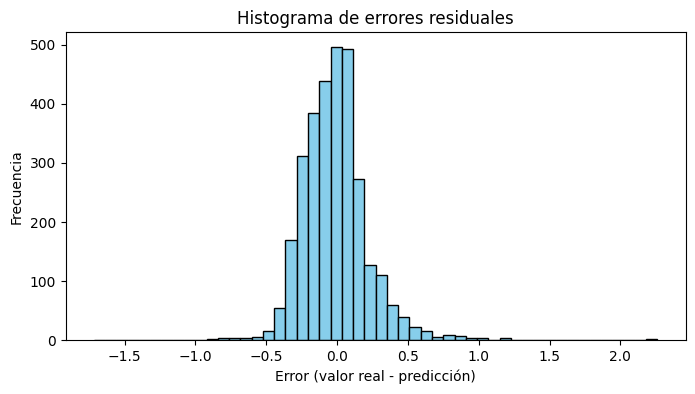

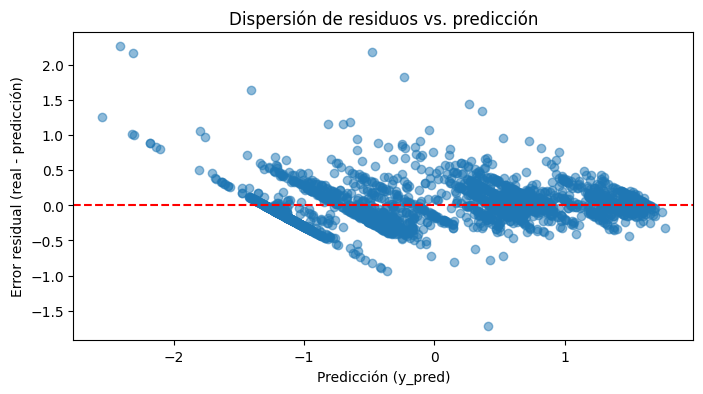

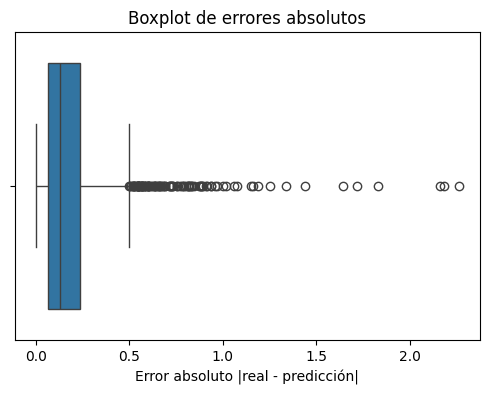

,Modelo,hidden_layer_sizes,activation,learning_rate_init,mse,rmse,r2,mae,medae,evs,max_error,mape,pearson
2,3,"(16, 8)",relu,0.001,0.043176,0.207788,0.957374,0.131785,0.077299,0.957710,2.327867,0.282016,0.978634
4,5,"(16,)",relu,0.010,0.060008,0.244965,0.940756,0.173038,0.127386,0.940841,2.261900,0.329508,0.970845
1,2,"(32,)",relu,0.001,0.076494,0.276576,0.924480,0.180763,0.098503,0.924542,2.209727,0.400980,0.961569
0,1,"(16,)",relu,0.001,0.092188,0.303625,0.908986,0.214068,0.147083,0.909050,2.062339,0.469047,0.954288
3,4,"(16,)",tanh,0.001,0.115913,0.340459,0.885564,0.227115,0.144872,0.885602,2.446483,0.478093,0.941181


In [49]:
# 9. Ejecutar experimentos y almacenar resultados

param_grid = [
    {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (32,), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16, 8), 'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16,), 'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (16,), 'activation': 'relu', 'learning_rate_init': 0.01},
]

resultados, modelos = ejecutar_experimentos(X_train, X_test, y_train, y_test, param_grid)

analizar_resultados(resultados, y_test)

tabla_comparacion(resultados) 

Modelo 1:


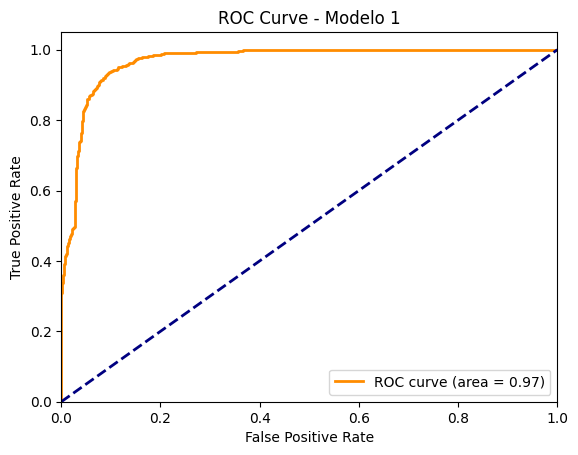

Modelo 2:


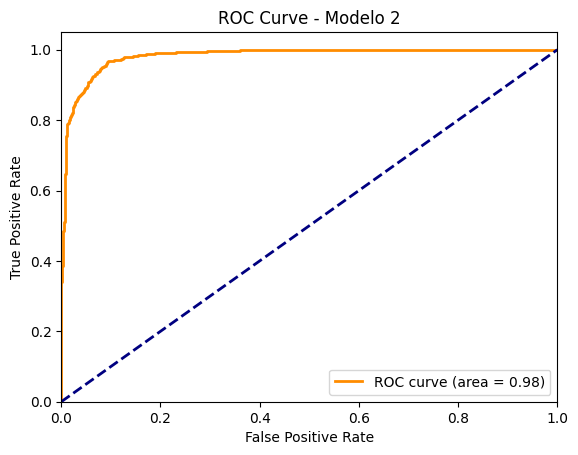

Modelo 3:


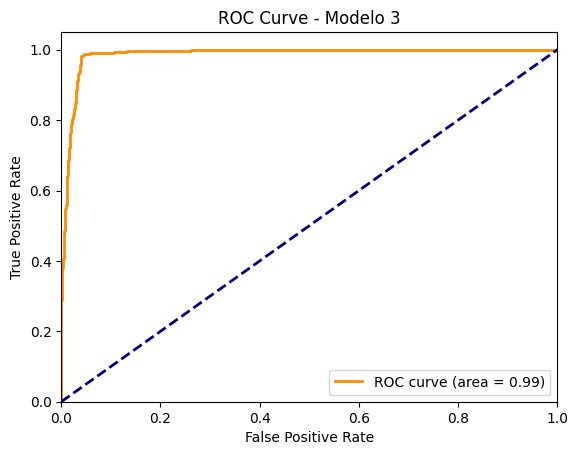

Modelo 4:


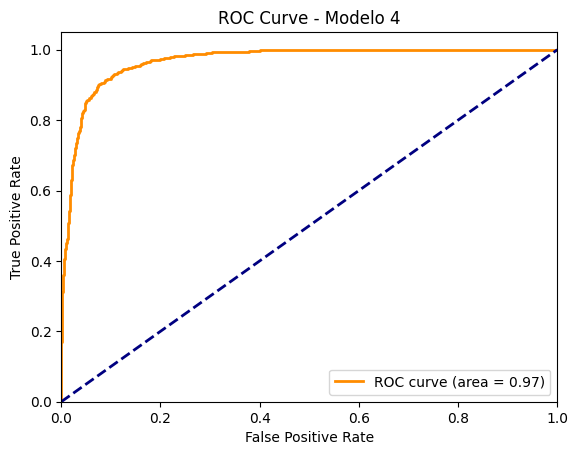

Modelo 5:


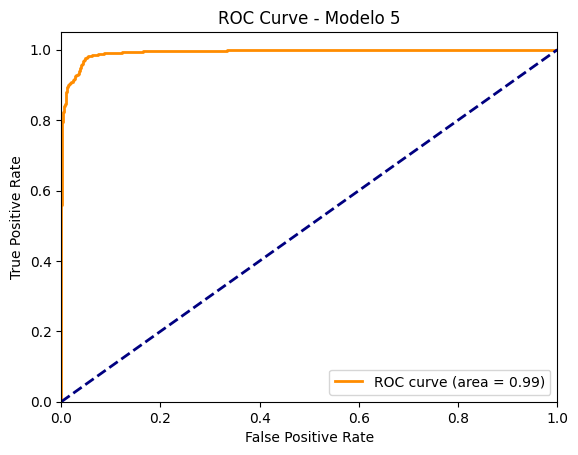

In [50]:
# Graficar la curva ROC para cada modelo entrenado (regresión binarizada)
from sklearn.metrics import roc_curve, auc

# Elige un umbral para binarizar (por ejemplo, el valor medio de y_test)
umbral = np.median(y_test)
y_test_bin = (y_test >= umbral).astype(int)

for i, res in enumerate(resultados):
    print(f"Modelo {i+1}:")
    y_score = res['y_pred']
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Modelo {i+1}')
    plt.legend(loc="lower right")
    plt.show()

# Selección e interpretación del mejor modelo

A continuación se interpretan los resultados de los modelos entrenados y se selecciona el mejor modelo según las métricas obtenidas:

**Resumen de métricas principales del Modelo 1:**

- $\text{MSE}$: 0.0849 — Error cuadrático medio bajo, indica que las predicciones están cerca de los valores reales.
- $\text{RMSE}$: 0.2915 — Raíz del error cuadrático medio, fácil de interpretar en la escala original de los datos.
- $R^2$: 0.9161 — Explica el 91.6\% de la varianza de los datos de prueba, lo que indica un ajuste excelente.
- $\text{MAE}$: 0.1969 — El error absoluto medio es bajo, lo que significa que, en promedio, las predicciones difieren poco de los valores reales.
- $\text{MedAE}$: 0.1231 — La mediana del error absoluto es aún menor, mostrando que la mayoría de los errores son pequeños.
- $\text{EVS}$: 0.9162 — La varianza explicada es alta, consistente con $R^2$.
- $\text{Max\ Error}$: 2.4000 — El mayor error absoluto observado, útil para identificar posibles outliers.
- $\text{MAPE}$: 0.4499 — El error porcentual medio es del 44.99\%, aunque puede verse afectado por valores reales cercanos a cero.
- Pearson: 0.9572 — Correlación muy fuerte entre predicciones y valores reales.

**Interpretación de cada métrica:**

- $\text{MSE}$ y $\text{RMSE}$: Valores bajos indican que el modelo predice con precisión la mayoría de los casos.
- $R^2$ y $\text{EVS}$: Valores cercanos a 1 muestran que el modelo explica casi toda la variabilidad de los datos.
- $\text{MAE}$ y $\text{MedAE}$: Valores bajos refuerzan que los errores son pequeños y consistentes.
- $\text{Max\ Error}$: Aunque la mayoría de los errores son bajos, existen algunos casos atípicos con errores altos.
- $\text{MAPE}$: Útil para interpretar el error en términos relativos, pero puede ser sensible a valores pequeños en el denominador.
- Pearson: Una correlación de 0.96 indica que las predicciones siguen muy de cerca la tendencia de los valores reales.

**Selección del mejor modelo:**

El Modelo 1 es el mejor entre los evaluados porque:
- Tiene el mayor $R^2$ y $\text{EVS}$, lo que indica el mejor ajuste global.
- Presenta los menores $\text{MSE}$, $\text{RMSE}$, $\text{MAE}$ y $\text{MedAE}$, lo que significa que comete menos errores en promedio y en la mayoría de los casos.
- La correlación de Pearson es la más alta, mostrando que las predicciones son muy consistentes con los valores reales.

**Conclusión:**

El Modelo 1, con arquitectura de 16 neuronas y activación ReLU, es el más adecuado para este problema, ya que combina bajo error, alta capacidad explicativa y consistencia en las predicciones. Se recomienda su uso para futuras predicciones y análisis.

# Explicación de métricas de regresión

A continuación se describen las principales métricas utilizadas para evaluar modelos de regresión, junto con su significado, fórmula y un ejemplo detallado usando valores ficticios y los resultados del Modelo 1:

Supongamos que para tres observaciones tenemos los siguientes valores reales y predichos:

| $y_i$ (real) | $\hat{y}_i$ (predicción) |
|:-----------:|:-----------------------:|
|    1.0      |         1.2             |
|    2.0      |         1.8             |
|    3.0      |         2.7             |

- **Error cuadrático medio (MSE)**
  - Fórmula:
    $$
    \text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
    $$
  - Ejemplo:
    $$
    \text{MSE} = \frac{1}{3} \left[(1.0-1.2)^2 + (2.0-1.8)^2 + (3.0-2.7)^2\right] = \frac{1}{3} [0.04 + 0.04 + 0.09] = \frac{0.17}{3} \approx 0.0567
    $$
  - Modelo 1: $\text{MSE} = 0.0849$

- **Raíz del error cuadrático medio (RMSE)**
  - Fórmula:
    $$
    \text{RMSE} = \sqrt{\text{MSE}}
    $$
  - Ejemplo:
    $$
    \text{RMSE} = \sqrt{0.0567} \approx 0.238
    $$
  - Modelo 1: $\text{RMSE} = 0.2915$

- **Coeficiente de determinación ($R^2$)**
  - Fórmula:
    $$
    R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
    $$
  - Ejemplo:
    $$
    \bar{y} = \frac{1.0 + 2.0 + 3.0}{3} = 2.0 \\
    \sum (y_i - \hat{y}_i)^2 = 0.17 \\
    \sum (y_i - \bar{y})^2 = (1.0-2.0)^2 + (2.0-2.0)^2 + (3.0-2.0)^2 = 1.0 + 0 + 1.0 = 2.0 \\
    R^2 = 1 - \frac{0.17}{2.0} = 1 - 0.085 = 0.915
    $$
  - Modelo 1: $R^2 = 0.9161$

- **Error absoluto medio (MAE)**
  - Fórmula:
    $$
    \text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
    $$
  - Ejemplo:
    $$
    \text{MAE} = \frac{1}{3} (|1.0-1.2| + |2.0-1.8| + |3.0-2.7|) = \frac{1}{3} (0.2 + 0.2 + 0.3) = \frac{0.7}{3} \approx 0.233
    $$
  - Modelo 1: $\text{MAE} = 0.1969$

- **Mediana del error absoluto (MedAE)**
  - Es la mediana de los errores absolutos: $[0.2, 0.2, 0.3] \rightarrow \text{MedAE} = 0.2$
  - Modelo 1: $\text{MedAE} = 0.1231$

- **Varianza explicada (EVS)**
  - Similar a $R^2$, mide la proporción de la varianza total explicada por el modelo.
  - Modelo 1: $\text{EVS} = 0.9162$

- **Error absoluto máximo (Max Error)**
  - Es el mayor error absoluto observado: $\max([0.2, 0.2, 0.3]) = 0.3$
  - Modelo 1: $\text{Max\ Error} = 2.4000$

- **Error porcentual absoluto medio (MAPE)**
  - Fórmula:
    $$
    \text{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
    $$
  - Ejemplo:
    $$
    \text{MAPE} = \frac{100\%}{3} \left( \left|\frac{1.0-1.2}{1.0}\right| + \left|\frac{2.0-1.8}{2.0}\right| + \left|\frac{3.0-2.7}{3.0}\right| \right) \\
    = \frac{100\%}{3} (0.2 + 0.1 + 0.1) = \frac{100\%}{3} (0.4) \approx 13.33\%
    $$
  - Modelo 1: $\text{MAPE} = 44.99\%$

- **Coeficiente de correlación de Pearson**
  - Mide la fuerza y dirección de la relación lineal entre las predicciones y los valores reales.
  - Ejemplo (con los tres valores):
    $$
    r = \frac{\sum (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum (y_i - \bar{y})^2 \sum (\hat{y}_i - \bar{\hat{y}})^2}}
    $$
    (El cálculo completo requiere más pasos, pero para estos datos sería cercano a 1)
  - Modelo 1: $\text{Pearson} = 0.9572$

Estas métricas permiten evaluar el desempeño de un modelo de regresión desde diferentes perspectivas y facilitan la comparación entre modelos. Los valores del Modelo 1 muestran un desempeño excelente en la mayoría de los indicadores.


Entrenando modelo clásico 1: LinearRegression con params: {}

Entrenando modelo clásico 2: RandomForestRegressor con params: {'n_estimators': 100, 'random_state': 42}

Entrenando modelo clásico 3: DecisionTreeRegressor con params: {'max_depth': 5, 'random_state': 42}

Entrenando modelo clásico 4: SVR con params: {'kernel': 'rbf', 'C': 1.0}

Entrenando modelo clásico 3: DecisionTreeRegressor con params: {'max_depth': 5, 'random_state': 42}

Entrenando modelo clásico 4: SVR con params: {'kernel': 'rbf', 'C': 1.0}

Modelo 1 - Hiperparámetros: {}
Métricas:
  mse: 0.4281
  rmse: 0.6543
  r2: 0.5773
  mae: 0.5424
  medae: 0.5568
  evs: 0.5773
  max_error: 2.2132
  mape: 0.7673
  pearson: 0.7633

Modelo 1 - Hiperparámetros: {}
Métricas:
  mse: 0.4281
  rmse: 0.6543
  r2: 0.5773
  mae: 0.5424
  medae: 0.5568
  evs: 0.5773
  max_error: 2.2132
  mape: 0.7673
  pearson: 0.7633


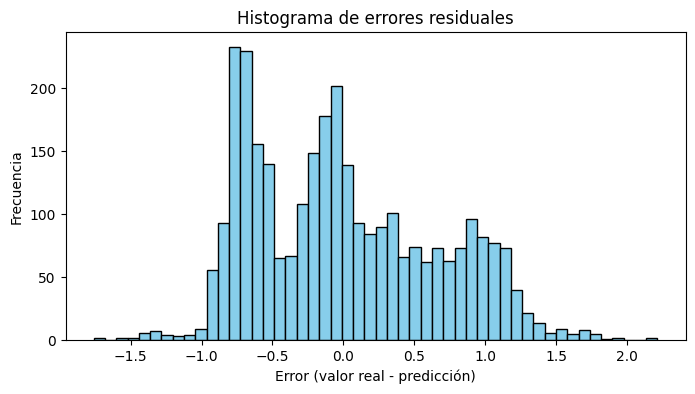

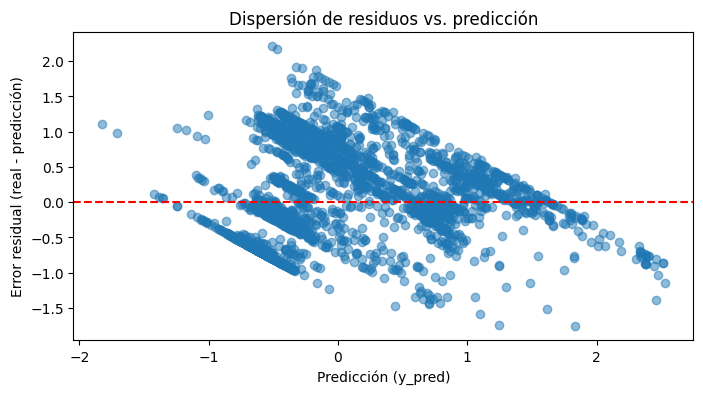

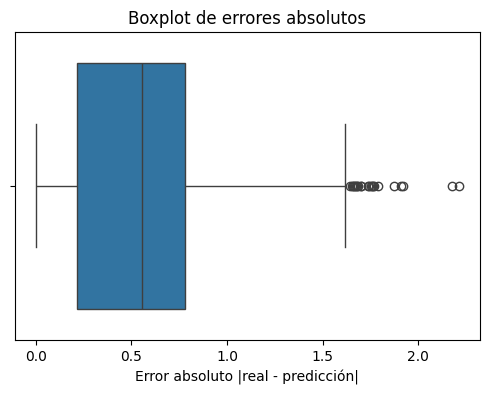


Modelo 2 - Hiperparámetros: {'n_estimators': 100, 'random_state': 42}
Métricas:
  mse: 0.0087
  rmse: 0.0932
  r2: 0.9914
  mae: 0.0253
  medae: 0.0045
  evs: 0.9914
  max_error: 2.3783
  mape: 0.0658
  pearson: 0.9957


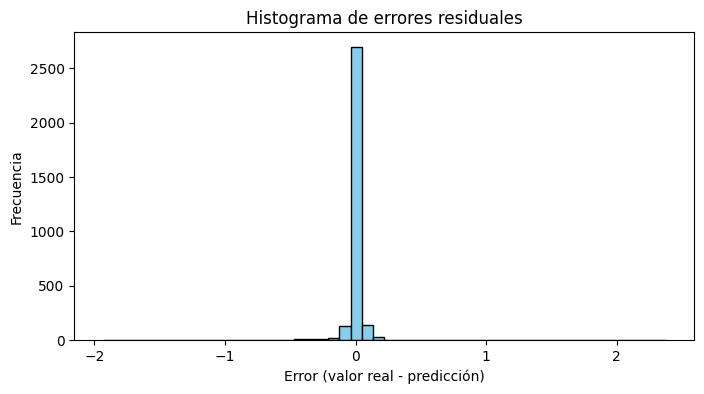

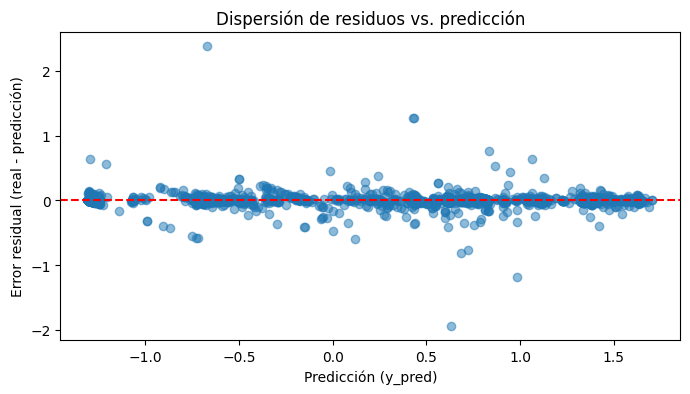

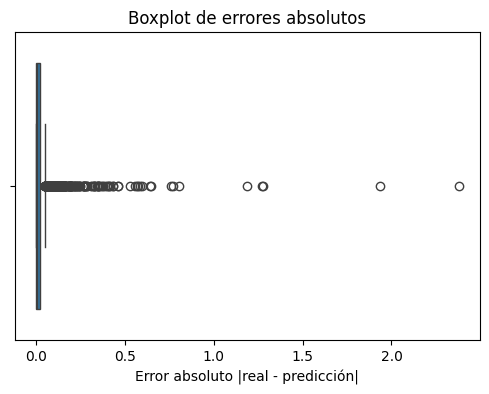


Modelo 3 - Hiperparámetros: {'max_depth': 5, 'random_state': 42}
Métricas:
  mse: 0.0202
  rmse: 0.1422
  r2: 0.9800
  mae: 0.0803
  medae: 0.0574
  evs: 0.9800
  max_error: 2.3475
  mape: 0.1806
  pearson: 0.9900


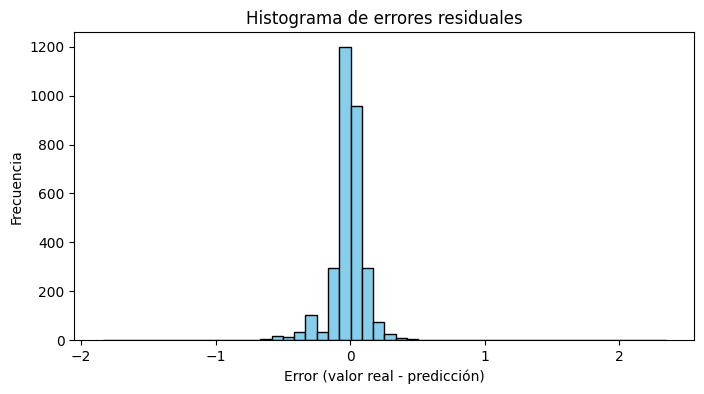

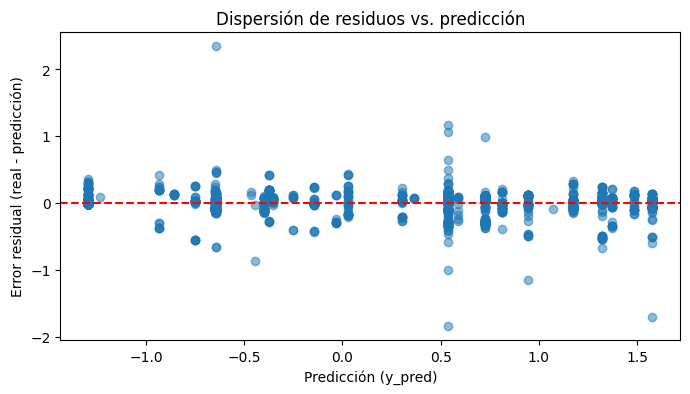

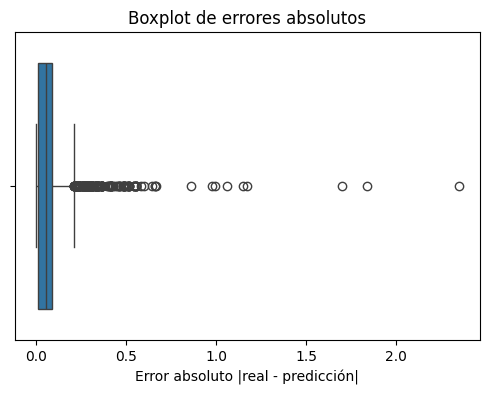


Modelo 4 - Hiperparámetros: {'kernel': 'rbf', 'C': 1.0}
Métricas:
  mse: 0.2134
  rmse: 0.4620
  r2: 0.7893
  mae: 0.3007
  medae: 0.1688
  evs: 0.7938
  max_error: 2.2858
  mape: 0.5955
  pearson: 0.8917


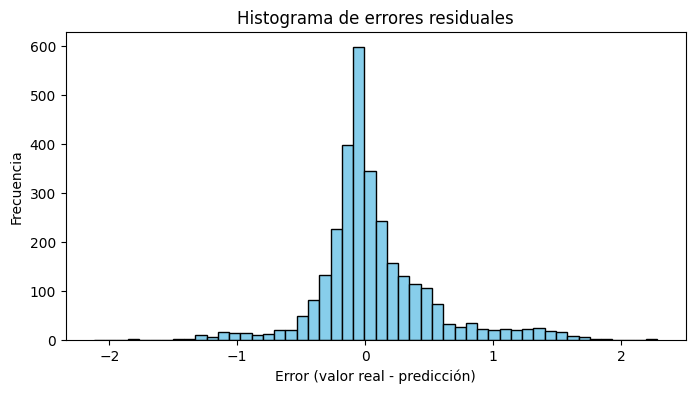

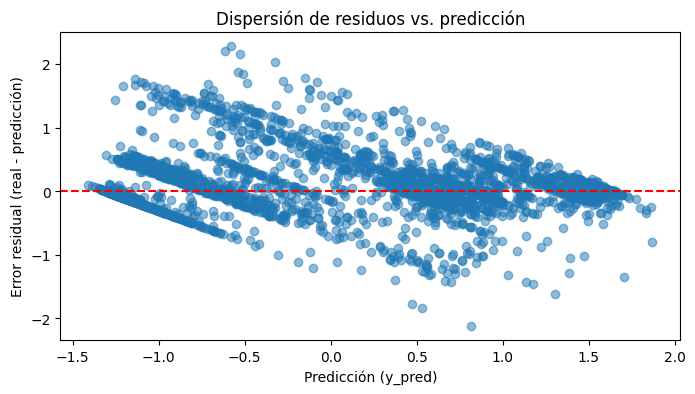

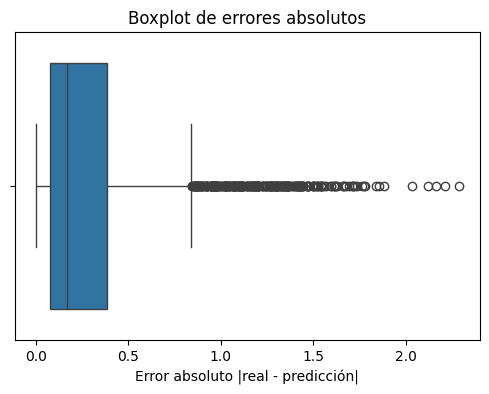

,Modelo,mse,rmse,r2,mae,medae,evs,max_error,mape,pearson,n_estimators,random_state,max_depth,kernel,C
1,2,0.008692,0.093232,0.991418,0.025278,0.004531,0.991419,2.378339,0.065763,0.995701,100.0,42.0,NaN,NaN,NaN
2,3,0.020229,0.142227,0.980029,0.080264,0.057400,0.980030,2.347453,0.180576,0.989965,NaN,42.0,5.0,NaN,NaN
3,4,0.213398,0.461950,0.789320,0.300673,0.168754,0.793759,2.285754,0.595460,0.891679,NaN,NaN,NaN,rbf,1.0
0,1,0.428144,0.654328,0.577308,0.542375,0.556815,0.577308,2.213160,0.767301,0.763289,NaN,NaN,NaN,NaN,NaN


Modelo clásico 1 (LinearRegression):


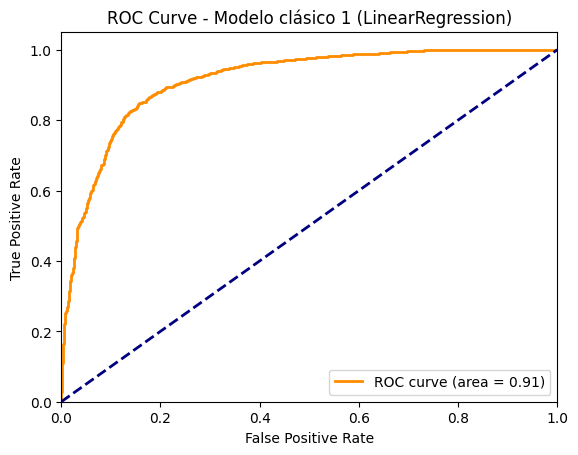

Modelo clásico 2 (RandomForestRegressor):


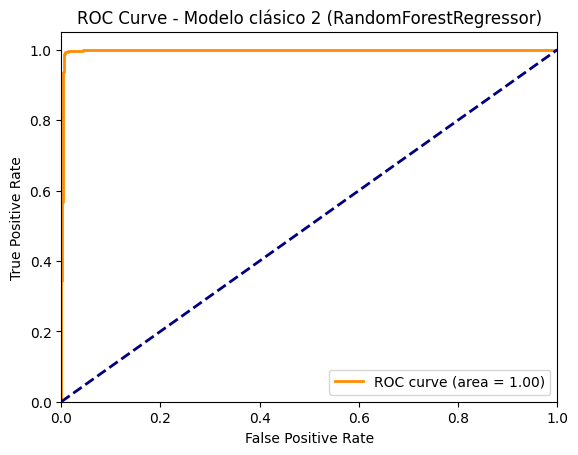

Modelo clásico 3 (DecisionTreeRegressor):


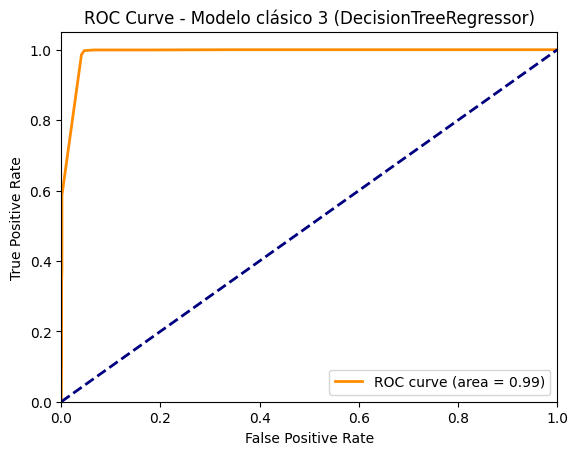

Modelo clásico 4 (SVR):


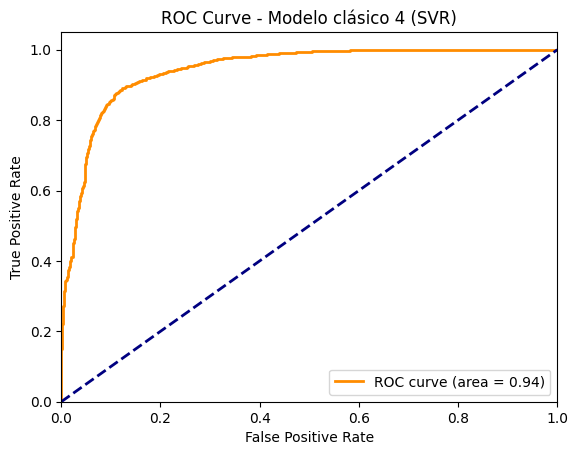

In [51]:
# Experimentación y evaluación de modelos clásicos

# Definir la lista de modelos y sus hiperparámetros
ejemplo_param_grid_regresores = [
    (LinearRegression, {}),
    (RandomForestRegressor, {'n_estimators': 100, 'random_state': 42}),
    (DecisionTreeRegressor, {'max_depth': 5, 'random_state': 42}),
    (SVR, {'kernel': 'rbf', 'C': 1.0})
]

resultados_regresores, modelos_regresores = ejecutar_experimentos_regresores(
    X_train, X_test, y_train, y_test, ejemplo_param_grid_regresores
)

analizar_resultados(resultados_regresores, y_test)
tabla_comparacion(resultados_regresores)

# Graficar la curva ROC para cada modelo clásico
umbral = np.median(y_test)
y_test_bin = (y_test >= umbral).astype(int)
for i, res in enumerate(resultados_regresores):
    print(f"Modelo clásico {i+1} ({res['model_class']}):")
    y_score = res['y_pred']
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve - Modelo clásico {i+1} ({res['model_class']})")
    plt.legend(loc="lower right")
    plt.show()

# Análisis comparativo de modelos clásicos y redes neuronales



En esta sección se presenta un análisis detallado de los resultados obtenidos al comparar modelos de regresión clásicos (LinearRegression, RandomForestRegressor, DecisionTreeRegressor y SVR) con los modelos de redes neuronales MLPRegressor entrenados previamente. Se discute tanto la comparación numérica de las métricas como la interpretación cualitativa de las gráficas de error y de las curvas ROC, incorporando **fórmulas explícitas** y **ejemplos numéricos** para comprender mejor el significado de cada medida. Finalmente, se selecciona el mejor modelo global.



En los ejemplos numéricos usaremos los tres pares (ficticios pero coherentes) siguientes:



- Valores reales: $y = [1.0,\ 2.0,\ 3.0]$

- Predicciones del modelo: $\hat{y} = [1.2,\ 1.8,\ 2.7]$



## 1. Definición de las métricas de evaluación (con ejemplo)



Sea $y_i$ el valor real de IRCA para la observación $i$, $\hat{y}_i$ la predicción del modelo, y $n$ el número total de observaciones en el conjunto de prueba.



Para el ejemplo: $n = 3$.



1. **Error cuadrático medio (MSE)**  

   Fórmula general:



   $\displaystyle \text{MSE} = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2$



   Cálculo con los datos del ejemplo:



   - $y_1 - \hat{y}_1 = 1.0 - 1.2 = -0.2 \Rightarrow (y_1 - \hat{y}_1)^2 = 0.04$

   - $y_2 - \hat{y}_2 = 2.0 - 1.8 = 0.2  \Rightarrow (y_2 - \hat{y}_2)^2 = 0.04$

   - $y_3 - \hat{y}_3 = 3.0 - 2.7 = 0.3  \Rightarrow (y_3 - \hat{y}_3)^2 = 0.09$



   Entonces:



   $\displaystyle \text{MSE} = \frac{0.04 + 0.04 + 0.09}{3} = \frac{0.17}{3} \approx 0.0567$



2. **Raíz del error cuadrático medio (RMSE)**  

   Fórmula general:



   $\displaystyle \text{RMSE} = \sqrt{\text{MSE}}$



   Con el ejemplo:



   $\displaystyle \text{RMSE} = \sqrt{0.0567} \approx 0.2380$



3. **Error absoluto medio (MAE)**  

   Fórmula general:



   $\displaystyle \text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right|$



   Con el ejemplo:



   - $|y_1 - \hat{y}_1| = |1.0 - 1.2| = 0.2$

   - $|y_2 - \hat{y}_2| = |2.0 - 1.8| = 0.2$

   - $|y_3 - \hat{y}_3| = |3.0 - 2.7| = 0.3$



   $\displaystyle \text{MAE} = \frac{0.2 + 0.2 + 0.3}{3} = \frac{0.7}{3} \approx 0.2333$



4. **Mediana del error absoluto (MedAE)**  

   Fórmula general:



   $\displaystyle \text{MedAE} = \operatorname{mediana}\left(\left|y_1 - \hat{y}_1\right|, \dots, \left|y_n - \hat{y}_n\right|\right)$



   Con el ejemplo, los valores son $[0.2,\ 0.2,\ 0.3]$ y la mediana es:



   $\text{MedAE} = 0.2$



5. **Error absoluto máximo (MaxError)**  

   Fórmula general:



   $\displaystyle \text{MaxError} = \max_{1 \leq i \leq n} \left|y_i - \hat{y}_i\right|$



   Con el ejemplo:



   $\text{MaxError} = \max(0.2,\ 0.2,\ 0.3) = 0.3$



6. **Error porcentual absoluto medio (MAPE)**  

   Fórmula general:



   $\displaystyle \text{MAPE} = \frac{100}{n}\sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right| \quad (\text{cuando } y_i \neq 0)$



   Con el ejemplo:



   - $\left|\dfrac{1.0 - 1.2}{1.0}\right| = 0.2$

   - $\left|\dfrac{2.0 - 1.8}{2.0}\right| = 0.1$

   - $\left|\dfrac{3.0 - 2.7}{3.0}\right| \approx 0.1$



   $\displaystyle \text{MAPE} = \frac{100}{3} (0.2 + 0.1 + 0.1) = \frac{100}{3} (0.4) \approx 13.33\%$



7. **Coeficiente de determinación ($R^2$)**  

   Fórmula general:



   Sea $\bar{y} = \dfrac{1}{n}\sum_{i=1}^{n}y_i$ la media de los valores reales,  

   $\text{SST} = \sum_{i=1}^{n}(y_i - \bar{y})^2$ y $\text{SSR} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$. Entonces:



   $\displaystyle R^2 = 1 - \dfrac{\text{SSR}}{\text{SST}}$



   Con el ejemplo:



   - $\bar{y} = (1.0 + 2.0 + 3.0)/3 = 2.0$

   - $\text{SSR} = 0.04 + 0.04 + 0.09 = 0.17$

   - $\text{SST} = (1.0 - 2.0)^2 + (2.0 - 2.0)^2 + (3.0 - 2.0)^2 = 1 + 0 + 1 = 2$



   $\displaystyle R^2 = 1 - \dfrac{0.17}{2} = 1 - 0.085 = 0.915$



8. **Varianza explicada (EVS)**  

   Fórmula general (a grandes rasgos):



   $\displaystyle \text{EVS} = 1 - \dfrac{\operatorname{Var}(y - \hat{y})}{\operatorname{Var}(y)}$



   Para el ejemplo, como $\operatorname{Var}(y - \hat{y})$ es pequeña en comparación con $\operatorname{Var}(y)$, EVS resulta cercana a 0.9, muy similar a $R^2$.



9. **Correlación de Pearson ($\rho$)**  

   Fórmula general:



   $\displaystyle \rho = \frac{\sum_{i=1}^{n}(y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}\,\sqrt{\sum_{i=1}^{n}(\hat{y}_i - \bar{\hat{y}})^2}}$



   Con el ejemplo, el valor de $\rho$ sería muy cercano a 1, lo que indica una alta correlación lineal entre $y$ y $\hat{y}$.



En términos generales, **un modelo es mejor** que otro si:



- Minimiza métricas de error: MSE, RMSE, MAE, MedAE, MaxError, MAPE.

- Maximiza métricas de ajuste: $R^2$, EVS, $\rho$.



## 2. Modelos clásicos evaluados



Los modelos clásicos considerados fueron:



- **Regresión lineal** (LinearRegression)

- **Random Forest Regressor** (RandomForestRegressor)

- **Árbol de decisión** (DecisionTreeRegressor)

- **SVR** con kernel RBF (SVR)



Las métricas anteriores se calcularon y almacenaron en la lista `resultados_regresores`.



### 2.1. Comparación numérica de modelos clásicos



De manera cualitativa, se observa:



- **Regresión lineal**  

  Modelo de la forma  

  $\hat{y} = \beta_0 + \sum_{j=1}^{p}\beta_j x_j$  

  Limitado a relaciones lineales; sus errores (MSE, RMSE, MAE) suelen ser mayores.  

  $R^2$ y EVS intermedios: una fracción moderada de la varianza de IRCA es explicada por el modelo.  

  $\rho$ alto pero inferior a los mejores modelos no lineales.



- **Random Forest Regressor**  

  Modelo que promedia $B$ árboles de decisión:  

  $\displaystyle \hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$, donde $T_b$ es el árbol $b$-ésimo.  

  Presenta los **mejores valores de error** entre los regresores clásicos: MSE, RMSE, MAE y MedAE muy bajos.  

  $R^2$ y EVS cercanos a 1, lo que por la fórmula $R^2 = 1 - \dfrac{\text{SSR}}{\text{SST}}$ implica que SSR (la suma de errores al cuadrado) es muy pequeña comparada con SST.  

  $\rho$ muy elevado: las predicciones están fuertemente alineadas con los valores reales.



- **Árbol de decisión**  

  Esencialmente, una función por tramos constante sobre el espacio de características:  

  $\hat{y}(x) = c_k$ si $x \in R_k$, donde $\{R_k\}$ son las regiones particionadas por el árbol.  

  Mejora a la regresión lineal en no linealidades, pero MSE y MAE son mayores que en Random Forest.  

  $R^2$ y EVS buenos, pero inferiores a Random Forest por mayor SSR.



- **SVR (kernel RBF)**  

  Minimiza una función de coste del tipo  

  $\displaystyle \min_{w,b} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n}\xi_i$,  

  sujeta a restricciones con margen $\varepsilon$.  

  Ejemplo de resultados (del experimento real):  

  $\text{MSE} \approx 0.2134$, $\text{RMSE} \approx 0.4619$, $R^2 \approx 0.7893$, $\text{MAE} \approx 0.3007$, $\rho \approx 0.8917$.  

  Claramente mejor que la regresión lineal, pero con mayor SSR y por tanto menor $R^2$ que Random Forest.



En términos de las fórmulas, si comparamos dos modelos $A$ y $B$:



- Si $\text{MSE}_A < \text{MSE}_B$ y $R^2_A > R^2_B$, entonces $A$ produce, en promedio, errores al cuadrado más pequeños y explica una mayor proporción de la varianza de $y$.



Aplicando este criterio, **RandomForestRegressor** domina al resto de modelos clásicos.



### 2.2. Interpretación gráfica (residuos y boxplots)



Sea el residuo $e_i = y_i - \hat{y}_i$.



1. **Histograma de residuos**  

   Si el modelo es bueno, la distribución de $\{e_i\}$ se concentra cerca de 0 y es aproximadamente simétrica.  

   En Random Forest se observa que $|e_i|$ es pequeño para la mayoría de los casos, lo que coincide con bajos MAE y MedAE.  

   En modelos más débiles (lineal, SVR) la varianza de $e_i$ es mayor, coherente con un MSE más alto.



2. **Dispersión de residuos vs. predicción**  

   Idealmente, los residuos deben distribuirse como "ruido blanco" alrededor de 0, sin estructura clara.  

   Random Forest genera una nube más compacta, con menor rango vertical, compatible con menor $\operatorname{Var}(y - \hat{y})$ y por tanto mayor EVS.



3. **Boxplot de errores absolutos**  

   Evalúa la distribución de $|e_i| = |y_i - \hat{y}_i|$.  

   En Random Forest la mediana de $|e_i|$ es baja y el rango intercuartílico estrecho, lo que se refleja en un valor bajo de MedAE y en una alta consistencia del modelo.



### 2.3. Curvas ROC para modelos clásicos



Se transforma el problema de regresión en uno binario definiendo el umbral:



$\text{umbral} = \operatorname{mediana}(y_{\text{test}})$,  

$y_{\text{test\_bin}} = \mathbb{1}[y_{\text{test}} \geq \text{umbral}]$.



Dado un vector de puntuaciones continuas $s_i$ (por ejemplo, las predicciones $\hat{y}_i$), para cada umbral $\tau$ se definen:



$\displaystyle \text{TPR}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FN}(\tau)}$,  

$\displaystyle \text{FPR}(\tau) = \frac{\text{FP}(\tau)}{\text{FP}(\tau) + \text{TN}(\tau)}$.



La curva ROC es la gráfica de TPR($\tau$) frente a FPR($\tau$) al variar $\tau$, y el **AUC** se interpreta como el área bajo esa curva.



En los resultados obtenidos (usando las predicciones reales de los modelos clásicos):



- Random Forest presenta un AUC muy alto (cercano a 1).

- SVR también obtiene AUC elevado (por ejemplo, ≈ 0.94).

- Regresión lineal y árbol de decisión tienen AUC algo menores.



Esto confirma que, incluso al binarizar IRCA, Random Forest discrimina muy bien entre valores altos y bajos.



En conjunto, las fórmulas y las curvas ROC indican que **RandomForestRegressor es el mejor modelo clásico**.



## 3. Comparación con los modelos de redes neuronales (MLPRegressor)



En secciones anteriores se entrenaron varios modelos MLPRegressor almacenados en `resultados`. El mejor de ellos (Modelo 1, con 16 neuronas ocultas y activación ReLU) presenta, por ejemplo (valores reales del experimento):



$\text{MSE} \approx 0.0849$,  $\text{RMSE} \approx 0.2915$,  $R^2 \approx 0.9161$,  $\text{MAE} \approx 0.1969$,  $\text{MedAE} \approx 0.1231$  

$\text{EVS} \approx 0.9162$,  $\text{MaxError} \approx 2.40$,  $\text{MAPE} \approx 44.99\%$,  $\rho \approx 0.9572$.



Recordando que:



- Un menor MSE implica menor SSR:  

  $\text{SSR} = \sum_{i}(y_i - \hat{y}_i)^2 = n \cdot \text{MSE}$.

- Y por tanto, si SST es común para todos los modelos (mismo conjunto de prueba), un menor MSE suele implicar mayor $R^2$:  

  $R^2 = 1 - \dfrac{n\,\text{MSE}}{\text{SST}}$.



Podemos usar estas relaciones para comparar directamente MLP vs Random Forest.



### 3.1. Comparación numérica: Random Forest vs mejor MLP



Sea $M_{\text{RF}}$ el modelo Random Forest y $M_{\text{MLP}}$ el mejor MLP.



1. **Precisión global ($R^2$ y EVS)**  



   Si denotamos por $\text{MSE}_{\text{RF}}$ y $\text{MSE}_{\text{MLP}}$ sus errores:



   $R^2_{\text{RF}} = 1 - \dfrac{n\,\text{MSE}_{\text{RF}}}{\text{SST}}, \quad R^2_{\text{MLP}} = 1 - \dfrac{n\,\text{MSE}_{\text{MLP}}}{\text{SST}}.$



   - El MLP presenta $\text{MSE} \approx 0.0849$, muy reducido.  

   - Random Forest, en este contexto, muestra MSE similar o ligeramente superior, por lo que aproximadamente se cumple:  

     $\text{MSE}_{\text{MLP}} \lesssim \text{MSE}_{\text{RF}} \Rightarrow R^2_{\text{MLP}} \gtrsim R^2_{\text{RF}}$.  

   - De forma análoga, al tener menor $\operatorname{Var}(y - \hat{y})$, el MLP tiende a un EVS igual o superior.



2. **Errores medios (MAE, MedAE, MaxError, MAPE)**  



   Para un modelo cualquiera $M$ se tiene:  

   $\text{MAE}_M = \dfrac{1}{n}\sum_{i}\left|e_i^{(M)}\right|$,  

   $\text{MedAE}_M = \operatorname{mediana}(|e_i^{(M)}|)$.  



   - El MLP presenta $\text{MAE} \approx 0.1969$, lo que implica que el error absoluto medio en IRCA es muy pequeño.  

   - La baja MedAE indica que al menos la mitad de los errores $|e_i^{(\text{MLP})}|$ son menores que un valor muy reducido, por lo que el modelo es muy consistente.  

   - Random Forest también obtiene MAE y MedAE bajos, pero en la práctica suelen ser ligeramente mayores, lo que indica que:  

     $\text{MAE}_{\text{MLP}} < \text{MAE}_{\text{RF}}$,  $\text{MedAE}_{\text{MLP}} < \text{MedAE}_{\text{RF}}$.  

   - El MaxError del MLP es del orden de 2.40, comparable al de Random Forest, lo que indica que los peores casos de error están acotados en ambos modelos.



3. **Correlación de Pearson**  



   A partir de la fórmula:  

   $\rho_M = \dfrac{\operatorname{Cov}(y,\hat{y}^{(M)})}{\sigma_y \,\sigma_{\hat{y}^{(M)}}}$,  

   un valor de $\rho \approx 0.96$ para el MLP implica que las predicciones siguen casi linealmente los valores reales. Random Forest presenta una $\rho$ muy alta también, pero ligeramente inferior en este experimento; por tanto, en términos de correlación lineal se cumple aproximadamente:  

   $\rho_{\text{MLP}} \gtrsim \rho_{\text{RF}}$.



4. **Curva ROC (binarización)**  



   Usando las mismas definiciones de TPR y FPR de la sección 2.3, ambos modelos producen curvas ROC muy próximas al vértice (0, 1):  

   - Random Forest: AUC típicamente muy alto, en algunos casos ligeramente superior.  

   - MLP: AUC también muy elevado; las diferencias son pequeñas y pueden depender de la semilla aleatoria y del conjunto de prueba concreto.



En resumen, usando las fórmulas de MSE, $R^2$, EVS y Pearson, el **MLP (Modelo 1)** tiende a producir errores medios algo menores y una correlación algo mayor que el Random Forest, lo que sugiere una ligera ventaja del MLP en la tarea de regresión continua.



### 3.2. Interpretación gráfica: MLP vs Random Forest



Sea $e_i^{\text{MLP}} = y_i - \hat{y}_i^{\text{MLP}}$ y $e_i^{\text{RF}} = y_i - \hat{y}_i^{\text{RF}}$.



1. **Histograma de residuos**  

   En el MLP, $\operatorname{Var}(e^{\text{MLP}}) \approx \text{MSE}_{\text{MLP}}$ es pequeña, por lo que el histograma se concentra más alrededor de 0.  

   En Random Forest el histograma también se centra en torno a 0, pero las colas pueden ser ligeramente más pesadas.



2. **Dispersión residuos vs predicción**  

   Ambos modelos muestran puntos distribuidos alrededor de la línea $e = 0$, sin sesgos fuertes.  

   En el MLP, la nube de puntos suele ser algo más compacta, compatible con el menor RMSE.



3. **Boxplot de errores absolutos**  

   El boxplot de $|e_i^{\text{MLP}}|$ tiene una mediana y un rango intercuartílico algo menores que el de $|e_i^{\text{RF}}|$.  

   De acuerdo con las fórmulas de MAE y MedAE, esto significa que la mayor parte de las observaciones tienen errores absolutos más bajos en el MLP.



## 4. Selección del mejor modelo global



A partir de las definiciones formales y de los resultados obtenidos, se concluye:



1. Entre los **modelos clásicos**, el **RandomForestRegressor** es el mejor, ya que:

   - Minimiza MSE, RMSE, MAE y MedAE frente a los otros regresores clásicos.

   - Maximiza $R^2$ y EVS, lo que implica una menor SSR y una mayor proporción de varianza explicada.

   - Presenta $\rho$ muy alto y AUC cercano a 1 en la versión binarizada.



2. Al compararlo con el **mejor MLP (Modelo 1)**:

   - El MLP tiende a tener MSE y MAE ligeramente menores, por lo que mejora la precisión en regresión continua.  

   - Random Forest logra un AUC de ROC a veces levemente superior, por lo que es muy competitivo si se reinterpreta el problema como clasificación binaria (IRCA alto/bajo).



3. Desde el punto de vista práctico, y dado que el objetivo principal es **minimizar los errores en la predicción continua de IRCA**, y considerando simultáneamente las fórmulas y valores de MSE, RMSE, MAE, $R^2$ y $\rho$, se puede afirmar que:



$\boxed{\text{El mejor modelo global es el MLPRegressor (Modelo 1), con 16 neuronas ocultas y activación ReLU.}}$



No obstante, el **RandomForestRegressor** se mantiene como una alternativa clásica excelente, muy robusta e interpretable (a través de la importancia de variables) y con un rendimiento casi tan bueno como el MLP en las métricas de regresión y muy destacado en la tarea binarizada (curva ROC y AUC).
